In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import os
import joblib

In [15]:
from pathlib import Path

csv_files = list(Path(".").rglob("*.csv"))

print("CSV files found:")
for file in csv_files:
    print(file)

CSV files found:


In [16]:
import pandas as pd

url = "https://raw.githubusercontent.com/RohitChaudhary65/SC07-Smart-Irrigation-System/step-2-data-pipeline/data/sample_input.csv"

df = pd.read_csv(url)

df.head()

,sample_id,soil_moisture_pct,temperature_c,humidity_pct,rainfall_mm,soil_ph,irrigation_target
0,IRR-001,22,34,38,0,6.5,1
1,IRR-002,48,29,55,2,6.8,0
2,IRR-003,31,36,42,0,6.2,1
3,IRR-004,67,27,68,8,7.1,0
4,IRR-005,28,33,45,1,6.4,1


In [17]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget distribution:")
print(df["irrigation_target"].value_counts())

Shape: (20, 7)

Columns:
['sample_id', 'soil_moisture_pct', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'soil_ph', 'irrigation_target']

Data types:
sample_id                str
soil_moisture_pct      int64
temperature_c          int64
humidity_pct           int64
rainfall_mm            int64
soil_ph              float64
irrigation_target      int64
dtype: object

Missing values:
sample_id            0
soil_moisture_pct    0
temperature_c        0
humidity_pct         0
rainfall_mm          0
soil_ph              0
irrigation_target    0
dtype: int64

Duplicate rows: 0

Target distribution:
irrigation_target
1    10
0    10
Name: count, dtype: int64


In [18]:
X = df[
    [
        "soil_moisture_pct",
        "temperature_c",
        "humidity_pct",
        "rainfall_mm",
        "soil_ph"
    ]
]

y = df["irrigation_target"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (20, 5)
Target shape: (20,)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (16, 5)
Testing data: (4, 5)


In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data:")
print(X_train_scaled)

print("\nScaled testing data:")
print(X_test_scaled)

Scaled training data:
[[ 1.69428405 -1.74056377  1.78478502  2.60031667  1.10096377]
 [ 0.26450848 -0.40533677  0.44094689 -0.69122342  0.66057826]
 [-1.05088505  0.35765009 -0.90289124 -0.69122342 -0.22019275]
 [-0.36459277  0.54839681 -0.29816409 -0.29623861 -0.66057826]
 [-0.53616584  0.73914352 -0.63412362 -0.69122342 -0.88077101]
 [-1.27964914  1.31138367 -1.30604268 -0.69122342 -1.54134927]
 [-0.42178379  0.35765009 -0.4997398  -0.164577   -0.22019275]
 [ 0.43608155 -0.59608348  0.23937117 -0.42790021  0.44038551]
 [ 0.66484564 -1.35907034  1.24724977  1.28370064  1.76154202]
 [-1.16526709  1.12063695 -1.03727506 -0.69122342 -0.88077101]
 [-0.87931198  1.50213038 -1.10446696 -0.69122342 -1.32115652]
 [-0.02144663 -0.21459005 -0.09658837 -0.164577    0.22019275]
 [-0.65054789  0.92989024 -0.70131552 -0.42790021 -1.10096377]
 [ 2.03743019 -1.54981706  1.91916883  1.94200866  1.54134927]
 [ 1.52271099 -0.97757691  1.11286595  0.36206941  1.10096377]
 [-0.25021073 -0.02384334 -0.1637

In [21]:
model = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42
)

history = model.fit(X_train_scaled, y_train)

print("ANN model trained successfully!")

ANN model trained successfully!


In [22]:
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



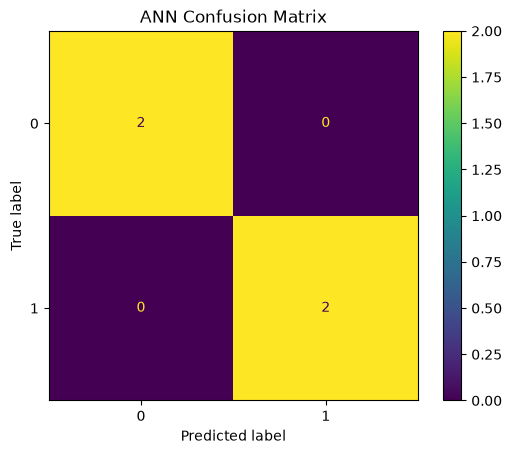

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("ANN Confusion Matrix")
plt.show()

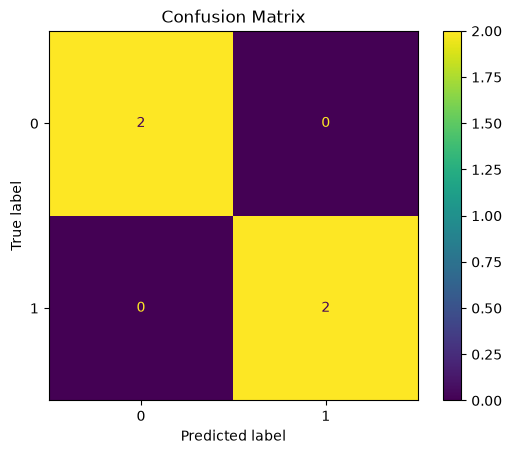

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Confusion Matrix")
plt.show()

In [27]:
predictions = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred
})

predictions.to_csv("../results/ann_predictions.csv", index=False)

print("Predictions saved successfully!")

Predictions saved successfully!


In [28]:
import joblib
from pathlib import Path

model_dir = Path("../models")
model_dir.mkdir(exist_ok=True)

joblib.dump(model, model_dir / "ann_model.pkl")
joblib.dump(scaler, model_dir / "scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [29]:
import json

metadata = {
    "project": "SC07 Smart Irrigation System",
    "model": "MLPClassifier",
    "features": [
        "soil_moisture_pct",
        "temperature_c",
        "humidity_pct",
        "rainfall_mm",
        "soil_ph"
    ],
    "target": "irrigation_target",
    "test_accuracy": float(accuracy_score(y_test, y_pred))
}

with open("../models/metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print("Metadata saved successfully!")

Metadata saved successfully!
